# Basics > Probability Calculator

<div class="alert alert-info">Simplify probability and value calculations using the Probability Calculator</div>

Calculate probabilities or values based on the Binomial, Chi-squared, Discrete, F, Exponential, Normal, Poisson, t, or Uniform distribution.

<!-- pyrsm-teaching-note: roadmap -->
## Teaching Roadmap

Use this notebook as the bridge between probability distributions and statistical tests. The shaded area in each plot can represent a probability, a p-value, or a rejection region depending on the inputs. Have students change the tails and confidence level to see how critical values move.


In [2]:
import pyrsm as rsm

In [3]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Testing batteries

Suppose Consumer Reports (CR) wants to test manufacturer claims about battery life. The manufacturer claims that more than 90% of their batteries will power a laptop for at least 12 hours of continuous use. CR sets up 20 identical laptops with the manufacturer's batteries. If the manufacturer's claims are accurate, what is the probability that 15 or more laptops are still running after 12 hours?


The description of the problem suggests we should consider a binomial distribution because we are interested in the number of successes in a series of independent trials. The probability of success is 0.9 and the number of trials is 20. The python code below calculates multiple probability results but we care specifically about the probability that 15 or more laptops are still running after 12 hours. That probability is 0.989 which is the sum of the probabilities of the green and red bars in the plot below.


Probability Calculator
Distribution: Binomial
n           : 20
p           : 0.9
Mean        : 18.0
St. dev     : 1.342
Lower bound : 
Upper bound : 15

P(X  = 15) = 0.032
P(X  < 15) = 0.011
P(X <= 15) = 0.043
P(X  > 15) = 0.957
P(X >= 15) = 0.989


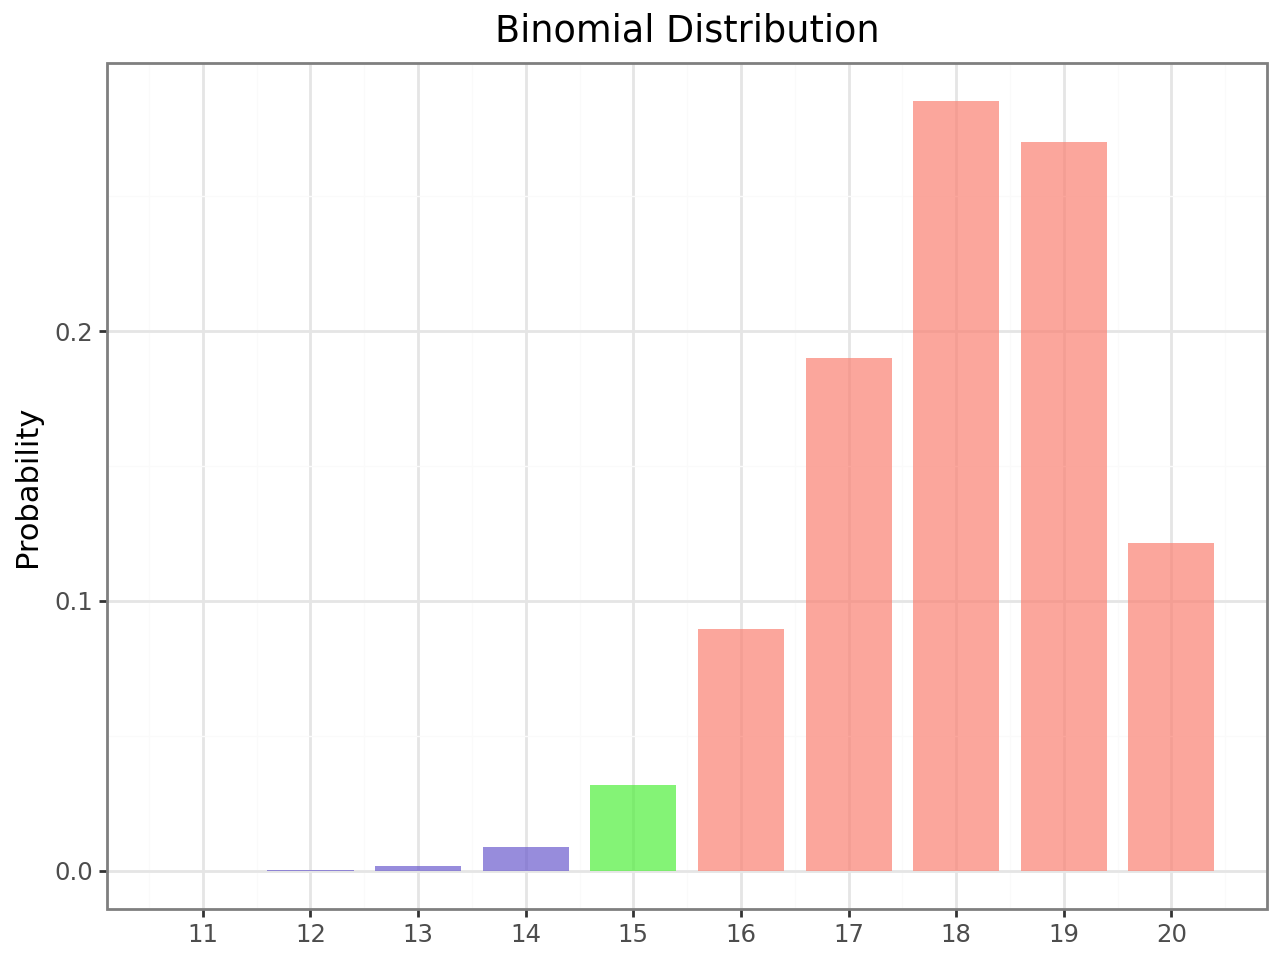

In [4]:
pc = rsm.basics.prob_calc("binom", n=20, p=0.9, ub=15)
pc.summary()
pc.plot()

We can replicate this result using the Probability Calculator in Radiant-for-R. The description of the problem suggests we should select `Binomial` from the `Distribution` dropdown. To find the probability, select `Values` as the `Input type` and enter `15` as the `Upper bound`. In the output below we can see that the probability is 0.989. The probability that exactly 15 laptops are still running after 12 hours is 0.032.

## Demand for headphones

A manufacturer wants to determine the appropriate inventory level for headphones required to achieve <a href="https://en.wikipedia.org/wiki/Service_level" target="_blank">service level</a> of at least 95%. Demand for the headphones obeys a normal distribution with a mean of 3000 and a standard deviation of 800.

To find the required number of headphones to hold in inventory we choose a normal distribution. We will specify the lower bound (`lb`) because the manufacturer wants to achieve a service level of at least 95%. The printed results show that the manufacturer should hold 4316 headphones in inventory to achieve a service level of at least 95%.

Probability Calculator
Distribution: Normal
Mean        : 3000
St. dev     : 800
Lower bound : 0.95
Upper bound : 1

P(X < 4315.883) = 0.95
P(X > 4315.883) = 0.05


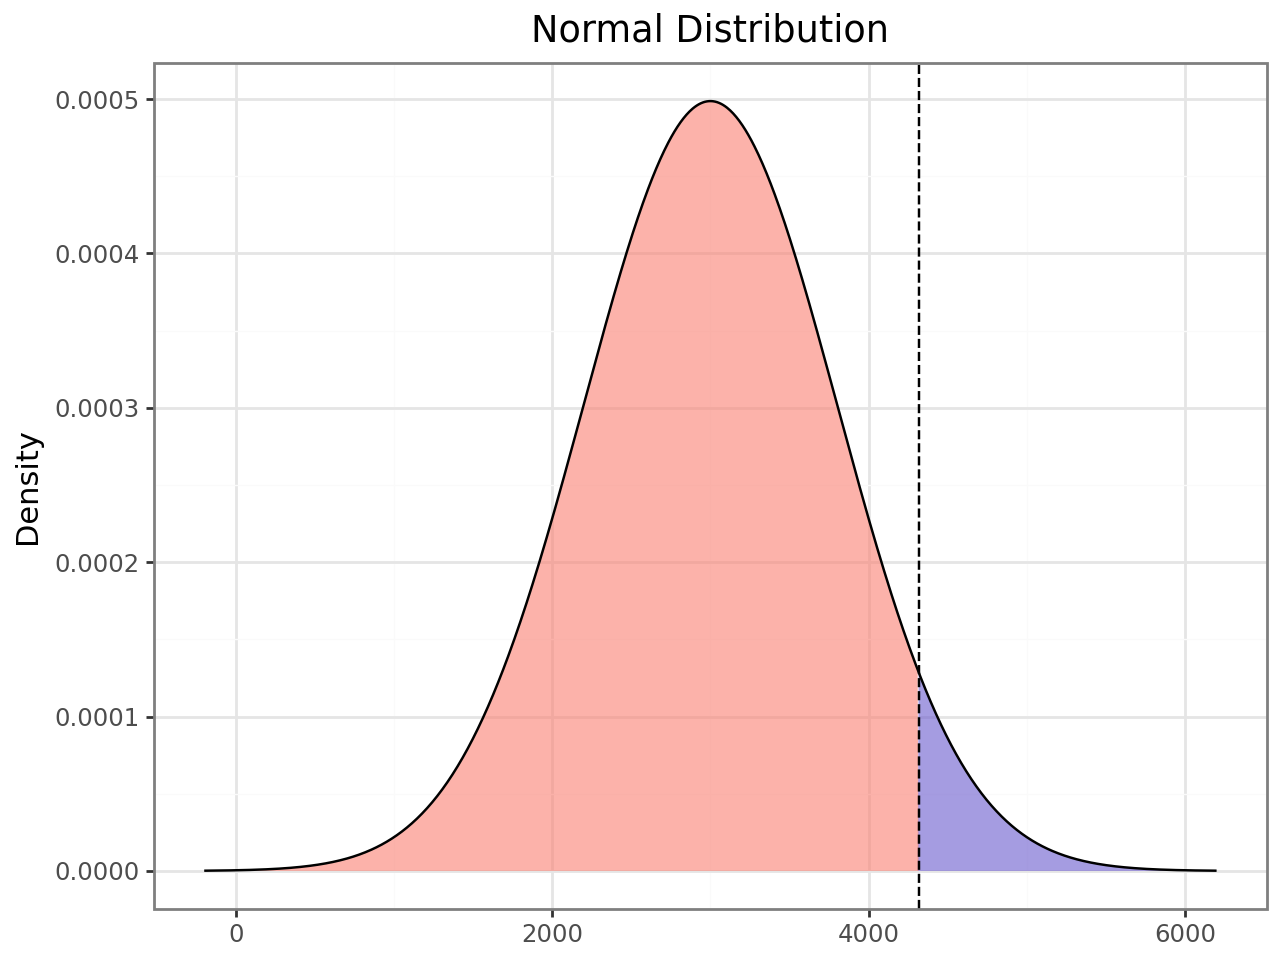

In [5]:
pc = rsm.basics.prob_calc("norm", mean=3000, sd=800, plb=0.95)
pc.summary()
pc.plot()

To see the methods and attributes associated with the `pc` object use `rsm.utils.odir`.

In [7]:
rsm.utils.odir(pc)

{'methods': ['plot', 'summary'],
 'attributes': ['args', 'dct', 'distribution', 'pretty_print_summary']}

The summary method has an arguments, i.e., `ret=True` what will return a dictionary with the result for possible use in other calculations.

In [11]:
pc.summary(ret=True)

{'Distribution': 'Normal',
 'Mean': 3000,
 'St. dev': 800,
 'Lower bound': 0.95,
 'Upper bound': '1',
 'P(X < 4315.883)': 0.95,
 'P(X > 4315.883)': 0.05}

We can replicate this result using the Probability Calculator in Radiant-for-R. To find the required number of headphones to hold in inventory choose `Normal` from the `Distribution` dropdown and then select `Probability` as the `Input type`. Enter `.95` as the `Upper bound`. In the output below we see the number of units to stock is 4316.



## Cups of ice cream

A **discrete** random variable can take on a limited (finite) number of possible values. The **probability distribution** of a discrete random variable lists these values and their probabilities. For example, the probability distribution of the number of cups of ice cream a customer buys could be described as follows:

* 40% of customers buy 1 cup;
* 30% of customers buy 2 cups;
* 20% of customers buy 3 cups;
* 10% of customers buy 4 cups.

We can use the probability distribution of a random variable to calculate its **mean** (or **expected value**) as follows;

$$
  E(C) = \mu_C = 1 \times 0.40 + 2 \times 0.30 + 3 \times 0.20 + 4 \times 0.10 = 2\,,
$$

where $\mu_C$ is the mean number of cups purchased. We can _expect_ a randomly selected customer to buy 2 cups. The variance is calculated as follow:

$$
  Var(C) = (1 - 2)^2 \times 0.4 + (2 - 2)^2 \times 0.3 + (3 - 2)^2 \times 0.2 + (4 - 2)^2 \times 0.1 = 1\,.
$$

To get the mean and standard deviation of the discrete probability distribution above, as well as the probability a customer will buy 2 or more cups (0.6), we can use the python code below. The values are provided in a list (`[1, 2, 3, 4]`), as are the corresponding probabilities (`[0.4, 0.3, 0.2, 0.1]`). The printed output shows the mean and standard deviation of the discrete probability distribution of interest, as well as the probability a customer will buy 2 or more cups (0.6) which corresponds the sum of the probabilities represented by the green and red bars in the plot below.


Probability Calculator
Distribution : Discrete
Values       : (1, 2, 3, 4)
Probabilities: [0.4, 0.3, 0.2, 0.1]
Mean         : 2.0
St. dev      : 1.0
Lower bound  : 2

P(X = 2) = 0.3
P(X < 2) = 0.4
P(X <= 2) = 0.7
P(X > 2) = 0.3
P(X >= 2) = 0.6


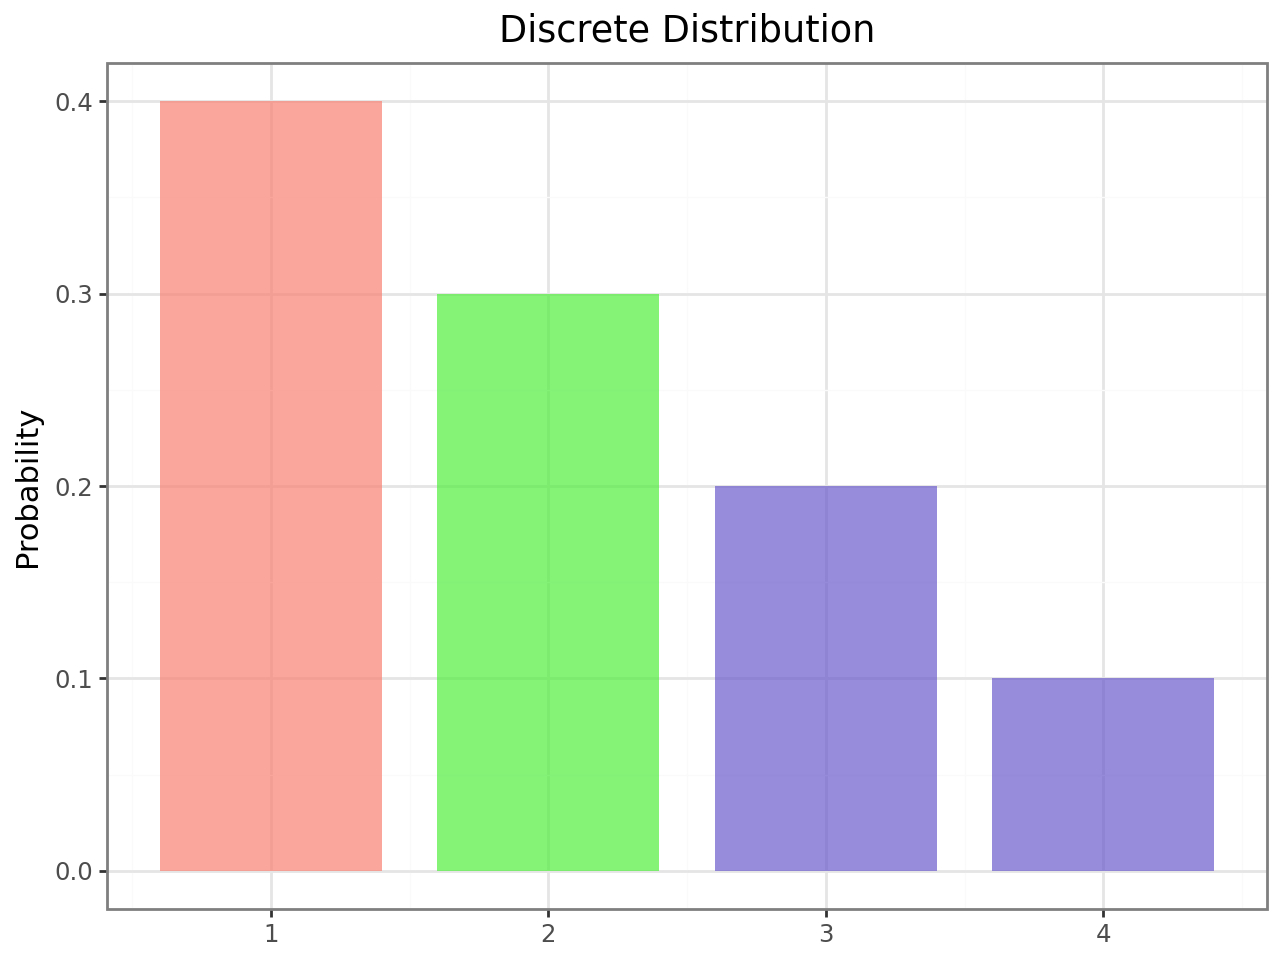

In [5]:
pc = rsm.basics.prob_calc("disc", v=[1, 2, 3, 4], p=[0.4, 0.3, 0.2, 0.1], lb=2)
pc.summary()
pc.plot()

We can replicate this result using the Probability Calculator in Radiant or R or Radiant for Python. To get the mean and standard deviation of the discrete probability distribution above, as well as the probability a customer will buy 2 or more cups (0.6), specify the following in the probability calculator.

## Hypothesis testing

You can also use the probability calculator to determine a `p.value` or a `critical value` for a statistical test. See the example files for `Single mean`, `Single proportion`, `Compare means`, `Compare proportions`, `Cross-tabs` and `Linear regression (OLS)` for details.

### Video Tutorials

To review the same analysis in Radiant-for-R, copy-and-paste the full command below into the RStudio console (i.e., the bottom-left window) and press return to gain access to all materials used in the probability calculator module of the <a href="https://www.youtube.com/playlist?list=PLNhtaetb48EdKRIY7MewCyvb_1x7dV3xw" target="_blank">Radiant Tutorial Series</a>:

<pre>usethis::use_course("https://www.dropbox.com/sh/zw1yuiw8hvs47uc/AABPo1BncYv_i2eZfHQ7dgwCa?dl=1")</pre>

<a href="https://youtu.be/UPL_8ujAXpww" target="_blank">Describing the Distribution of a Discrete Random
	Variable (#1)</a>

* This video shows how to summarize information about a discrete random variable using the probability calculator in Radiant
* Topics List:
    - Calculate the mean and variance for a discrete random variable by hand
    - Calculate the mean, variance, and select probabilities for a discrete random variable in Radiant

<a href="https://youtu.be/30YsxCTbDTc" target="_blank">Describing Normal and Binomial Distributions in Radiant(#2)</a>

* This video shows how to summarize information about Normal and Binomial distributions using the probability calculator in Radiant
* Topics List:
    - Calculate probabilities of a random variable following a Normal distribution in Radiant
    - Calculate probabilities of a random variable following a Binomial distribution by hand
    - Calculate probabilities of a random variable following a Binomial distribution in Radiant

<a href="https://youtu.be/LbwUpEwTJ_Q" target="_blank">Describing Uniform and Binomial Distributions in Radiant(#3)</a>

* This video shows how to summarize information about Uniform and Binomial distributions using the probability calculator in Radiant
* Topics List:
    - Calculate probabilities of a random variable following a Uniform distribution in Radiant
    - Calculate probabilities of a random variable following a Binomial distribution in Radiant

<a href="https://youtu.be/XC2yN5BY8jg" target="_blank">Providing Probability Bounds(#4)</a>

* This video demonstrates how to provide probability bounds in Radiant 
* Topics List:
    - Use probabilities as input type
    - Round up the cutoff value


© Vincent Nijs (2026)

## Additional examples


In [6]:
pc = rsm.basics.prob_calc("unif", min=0, max=10, lb=2, ub=5)
pc.summary()


Probability Calculator
Distribution    : Uniform
Min             : 0
Max             : 10
Mean            : 5.0
St. dev         : 2.887
Lower bound     : 2
Upper bound     : 5
1 - P(2 < X < 5): 0.7

P(X < 2) =   0.2
P(X > 2) =   0.8
P(X < 5) =   0.5
P(X > 5) =   0.5
P(2 < X < 5) = 0.3
